# Two-session whole-brain stop-signal analysis with Boldtailor

This executable example follows two stop-signal runs from BIDS discovery through a common-mask whole-brain fit, compact diagnostics, provenance projection, and transactional publication. It reports only shareable labels, basenames, array summaries, and derivative-relative paths.

In [ ]:
import os
from pathlib import Path

BIDS_ROOT = Path(
    os.environ.get("BOLDTAILOR_BIDS_ROOT", "/Users/poldrack/data_unsynced/rdoc_fmri")
)
FMRIPREP_ROOT = BIDS_ROOT / "derivatives" / "fmri_25.2.0"
SUBJECT = "sub-s4"
DEFAULT_SESSIONS = ("ses-02", "ses-04", "ses-06", "ses-08", "ses-10")


def _configured_sessions():
    selection = os.environ.get("BOLDTAILOR_SESSIONS")
    if selection is None:
        return DEFAULT_SESSIONS
    sessions = tuple(value.strip() for value in selection.split(","))
    if len(sessions) != 2 or not all(sessions):
        raise ValueError(
            "BOLDTAILOR_SESSIONS must select exactly two non-empty sessions"
        )
    return sessions


SESSIONS = _configured_sessions()
TASK = "stopSignal"
RUN = "run-01"
SPACE = "MNI152NLin2009cAsym"
RESOLUTION = 2
MASK_STRATEGY = "intersection"
MINIMUM_MEMORY_GIB = 32
PERSIST_DERIVATIVES = False
OVERWRITE_EXISTING = False
TEMPORARY_PARENT = os.environ.get("BOLDTAILOR_TEMP_ROOT")

## Imports and discovery

Boldtailor keeps package initializers empty, so this notebook imports each public module explicitly. Discovery resolves one raw events table and the matching preprocessed BOLD image, brain mask, and confounds table for each session. The display deliberately contains session labels and basenames only.

In [2]:
import importlib
import matplotlib.pyplot as plt
import nilearn.plotting as plotting
import numpy as np
import pandas as pd
from IPython.display import display

import boldtailor.bids_provenance as bids_provenance
import boldtailor.data as data
import boldtailor.fit as fit
import boldtailor.model as model
import boldtailor.publication as publication


def _load_example_module():
    try:
        return importlib.import_module("examples.stop_signal_demo")
    except ModuleNotFoundError as error:
        if error.name != "examples":
            raise
        return importlib.import_module("stop_signal_demo")


_example = _load_example_module()
common_brain_mask = _example.common_brain_mask
discover_run_inputs = _example.discover_run_inputs
estimate_signal_memory_gib = _example.estimate_signal_memory_gib
load_run = _example.load_run
make_masker = _example.make_masker
protected_source_paths = _example.protected_source_paths
publication_destination = _example.publication_destination
result_artifacts = _example.result_artifacts
run_sources = _example.run_sources
whole_brain_image = _example.whole_brain_image

TRIAL_TYPES = ("go_success", "go_failure", "stop_success", "stop_failure")
CONFOUNDS = (
    "trans_x",
    "trans_y",
    "trans_z",
    "rot_x",
    "rot_y",
    "rot_z",
    "framewise_displacement",
)
inputs = tuple(
    discover_run_inputs(
        BIDS_ROOT,
        FMRIPREP_ROOT,
        subject=SUBJECT,
        session=session,
        task=TASK,
        run=RUN,
        space=SPACE,
        resolution=RESOLUTION,
    )
    for session in SESSIONS
)
display(
    pd.DataFrame(
        [
            {
                "session": item.session,
                "events": item.events.name,
                "bold": item.bold.name,
                "mask": item.mask.name,
                "confounds": item.confounds.name,
            }
            for item in inputs
        ]
    )
)

,session,events,bold,mask,confounds
0,ses-06,sub-s4_ses-06_task-stopSignal_run-01_events.tsv,sub-s4_ses-06_task-stopSignal_run-01_space-MNI...,sub-s4_ses-06_task-stopSignal_run-01_space-MNI...,sub-s4_ses-06_task-stopSignal_run-01_desc-conf...
1,ses-08,sub-s4_ses-08_task-stopSignal_run-01_events.tsv,sub-s4_ses-08_task-stopSignal_run-01_space-MNI...,sub-s4_ses-08_task-stopSignal_run-01_space-MNI...,sub-s4_ses-08_task-stopSignal_run-01_desc-conf...


## Common-mask whole-brain loading

The intersection of both fMRIPrep brain masks defines one shared feature axis. A single fitted masker extracts both runs without standardizing, detrending, smoothing, or temporal filtering. This analysis assumes at least 32 GiB of memory and does not chunk features; resource failures are surfaced instead of changing the analysis.

{'mask_shape': [97, 115, 97],
 'common_voxel_count': 289425,
 'scan_counts': [343, 337],
 'signal_shapes': [[343, 289425], [337, 289425]],
 'estimated_signal_memory_gib': 1.4663413166999817}

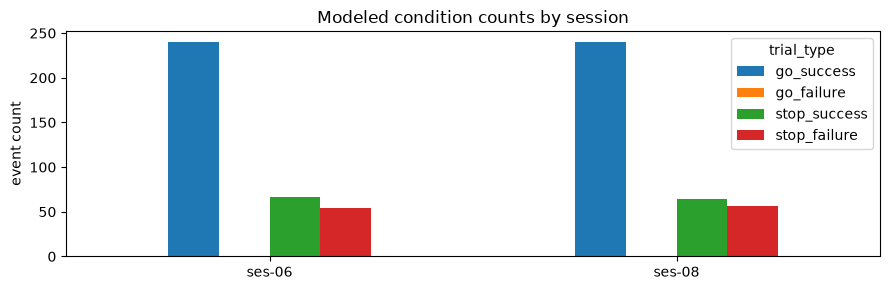

In [3]:
common_mask = common_brain_mask(inputs)
masker = make_masker(common_mask)
loaded_runs = tuple(
    load_run(
        item,
        masker,
        trial_types=TRIAL_TYPES,
        confound_names=CONFOUNDS,
    )
    for item in inputs
)
common_voxel_count = int(np.asarray(common_mask.dataobj, dtype=bool).sum())
scan_counts = [len(run.frame_times) for run in loaded_runs]
estimated_signal_memory_gib = estimate_signal_memory_gib(
    scan_counts, common_voxel_count
)
display(
    {
        "mask_shape": list(common_mask.shape),
        "common_voxel_count": common_voxel_count,
        "scan_counts": scan_counts,
        "signal_shapes": [list(run.signals.shape) for run in loaded_runs],
        "estimated_signal_memory_gib": estimated_signal_memory_gib,
    }
)
condition_counts = pd.DataFrame(
    {run.inputs.session: run.events.trial_type.value_counts() for run in loaded_runs}
).T.fillna(0).astype(int)
axes = condition_counts.reindex(columns=TRIAL_TYPES, fill_value=0).plot.bar(
    figsize=(9, 3), ylabel="event count", rot=0
)
axes.set_title("Modeled condition counts by session")
plt.tight_layout()
plt.show()

## Array ingestion

The loader hands time-by-voxel arrays and run-specific tables to Boldtailor. Dataset-relative source descriptors provide stable provenance without exposing the absolute dataset root or making the modeling API read those files.

In [4]:
mask_metadata = {
    "strategy": "intersection",
    "shape": list(common_mask.shape),
    "affine": common_mask.affine.tolist(),
    "voxel_count": common_voxel_count,
}
masker_settings = {
    "standardize": False,
    "detrend": False,
    "smoothing_fwhm": None,
    "low_pass": None,
    "high_pass": None,
    "reports": False,
}
resource_assumptions = {
    "minimum_memory_gib": 32,
    "feature_chunking": False,
    "estimated_signal_memory_gib": estimated_signal_memory_gib,
}
transformed_signals = [
    {
        "session": run.inputs.session,
        "shape": list(run.signals.shape),
        "dtype": str(run.signals.dtype),
    }
    for run in loaded_runs
]
contrast_definitions = {
    "successful_inhibition": "stop_success - stop_failure",
    "stop_vs_go": "(stop_success + stop_failure) - go_success",
    "go_success_vs_baseline": "go_success",
}
shareable_configuration = {
    "subject": SUBJECT,
    "task": TASK,
    "sessions": list(SESSIONS),
    "mask": mask_metadata,
    "masker": masker_settings,
    "resources": resource_assumptions,
    "transformed_signals": transformed_signals,
    "contrasts": contrast_definitions,
}
provenance_metadata = {
    "example": "two-session stop-signal whole-brain",
    "sessions": list(SESSIONS),
    "mask": mask_metadata,
    "masker": masker_settings,
    "resources": resource_assumptions,
    "transformed_signals": transformed_signals,
    "contrasts": contrast_definitions,
}
display(shareable_configuration)
analysis_data = data.from_arrays(
    [run.signals for run in loaded_runs],
    [run.events for run in loaded_runs],
    frame_times=[run.frame_times for run in loaded_runs],
    confounds=[run.confounds for run in loaded_runs],
    sources=[run_sources(item, BIDS_ROOT) for item in inputs],
    provenance_metadata=provenance_metadata,
)

{'subject': 'sub-s4',
 'task': 'stopSignal',
 'sessions': ['ses-06', 'ses-08'],
 'mask': {'strategy': 'intersection',
  'shape': [97, 115, 97],
  'affine': [[2.0, 0.0, 0.0, -96.5],
   [0.0, 2.0, 0.0, -132.5],
   [0.0, 0.0, 2.0, -78.5],
   [0.0, 0.0, 0.0, 1.0]],
  'voxel_count': 289425},
 'masker': {'standardize': False,
  'detrend': False,
  'smoothing_fwhm': None,
  'low_pass': None,
  'high_pass': None,
  'reports': False},
 'resources': {'minimum_memory_gib': 32,
  'feature_chunking': False,
  'estimated_signal_memory_gib': 1.4663413166999817},
 'transformed_signals': [{'session': 'ses-06',
   'shape': [343, 289425],
   'dtype': 'float64'},
  {'session': 'ses-08', 'shape': [337, 289425], 'dtype': 'float64'}],
 'contrasts': {'successful_inhibition': 'stop_success - stop_failure',
  'stop_vs_go': '(stop_success + stop_failure) - go_success',
  'go_success_vs_baseline': 'go_success'}}

## Run-specific designs and fit

Each run receives its own design matrix from its observed trial types rather than fabricated empty regressors. All three contrasts are estimable in both runs, and AR(1) noise is fitted jointly across the shared whole-brain feature axis.

,session,design_columns
0,ses-06,"(go_success, stop_failure, stop_success, trans..."
1,ses-08,"(go_success, stop_failure, stop_success, trans..."


,session,nuisance_design_columns
0,ses-06,"(trans_x, trans_y, trans_z, rot_x, rot_y, rot_..."
1,ses-08,"(trans_x, trans_y, trans_z, rot_x, rot_y, rot_..."


{'definition': 'full_r2 - nuisance_r2',
 'clip_below_zero': True,
 'nuisance_model': {'events': False,
  'confounds': ['trans_x',
   'trans_y',
   'trans_z',
   'rot_x',
   'rot_y',
   'rot_z',
   'framewise_displacement'],
  'drift_model': 'cosine',
  'high_pass': 0.01,
  'drift_order': 1,
  'noise_model': 'ar1'},
 'raw_min_delta_r2': -0.008846197559552182,
 'negative_voxel_count': 129,
 'mean_delta_r2': 0.008795061810013115,
 'max_delta_r2': 0.1336665383984702}

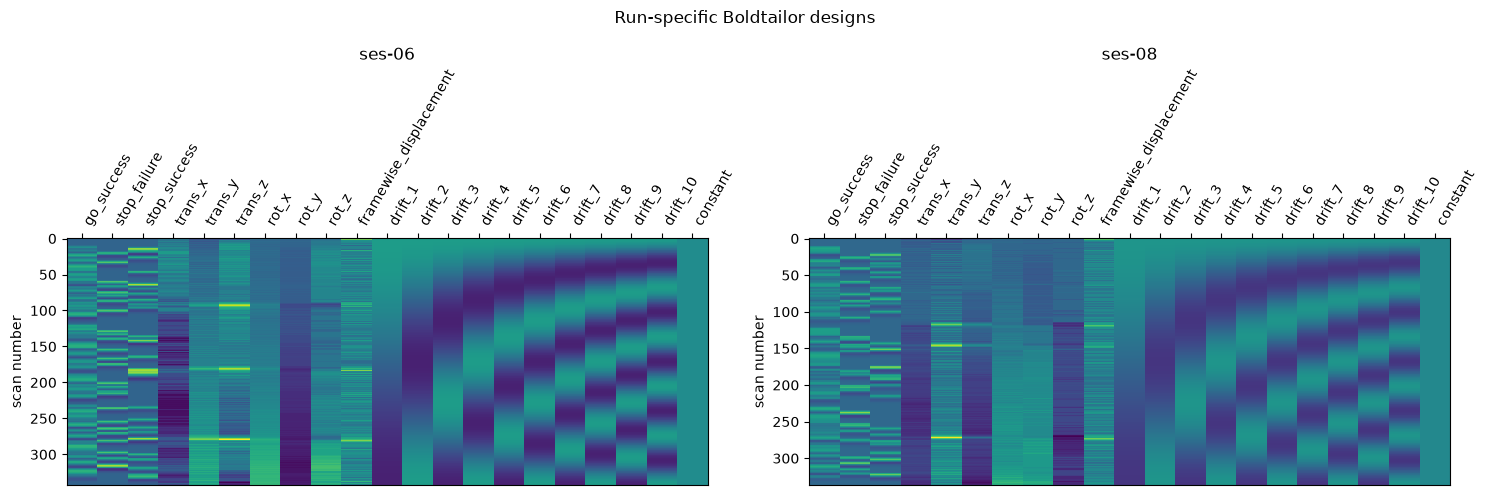

In [5]:
model_spec = model.ModelSpec(
    contrasts={
        "successful_inhibition": "stop_success - stop_failure",
        "stop_vs_go": "(stop_success + stop_failure) - go_success",
        "go_success_vs_baseline": "go_success",
    },
    confounds=CONFOUNDS,
    noise_model="ar1",
)
result = fit.fit(analysis_data, model_spec)
task_delta = fit.task_delta_r2(analysis_data, model_spec, result)
variance_partition = {
    "definition": "full_r2 - nuisance_r2",
    "clip_below_zero": True,
    "nuisance_model": {
        "events": False,
        "confounds": list(CONFOUNDS),
        "drift_model": model_spec.drift_model,
        "high_pass": model_spec.high_pass,
        "drift_order": model_spec.drift_order,
        "noise_model": model_spec.noise_model,
    },
    "raw_min_delta_r2": task_delta.raw_min,
    "negative_voxel_count": task_delta.negative_voxel_count,
    "mean_delta_r2": float(task_delta.delta_r2.mean()),
    "max_delta_r2": float(task_delta.delta_r2.max()),
}
shareable_configuration["variance_partition"] = variance_partition
design_columns = tuple(tuple(frame.columns) for frame in result.design_matrices)
nuisance_design_columns = tuple(
    tuple(frame.columns) for frame in task_delta.nuisance_design_matrices
)
display(pd.DataFrame({"session": SESSIONS, "design_columns": design_columns}))
display(
    pd.DataFrame(
        {
            "session": SESSIONS,
            "nuisance_design_columns": nuisance_design_columns,
        }
    )
)
display(variance_partition)

figure, design_axes = plt.subplots(1, 2, figsize=(15, 5))
for session, design, axis in zip(
    SESSIONS, result.design_matrices, design_axes, strict=True
):
    plotting.plot_design_matrix(design, axes=axis)
    axis.set_title(session)
figure.suptitle("Run-specific Boldtailor designs")
figure.tight_layout()
plt.show()

## Results and diagnostics

The compact tables summarize every result accessor without dumping voxelwise arrays. Whole-brain z-statistic and aggregate R-squared maps are shown without inferential thresholding.

('successful_inhibition', 'stop_vs_go', 'go_success_vs_baseline')

,contrast,mean_effect,mean_variance,mean_stat,mean_z_score,min_one_sided_p_value
0,successful_inhibition,-2.095791,104.983192,-0.163555,-0.163359,5.768963e-05
1,stop_vs_go,-10.701852,152.087440,-0.903512,-0.902094,1.844364e-12
2,go_success_vs_baseline,-10.186376,46.244296,-1.608254,-1.604349,1.640609e-14


,scope,mean_r2
0,ses-06,0.334671
1,ses-08,0.300569
2,aggregate,0.328229


,excluded_event_count,min_onset_cutoff
ses-06,0,-24.0
ses-08,0,-24.0


{'warnings': []}

{'execution_id': '89413397-6ca1-49fa-b264-400dd3f91a63',
 'analysis_fingerprint': '23ee8d142a0510571423092b75e43fe9c6a4f06b09463db5158c9aea702fc33e'}

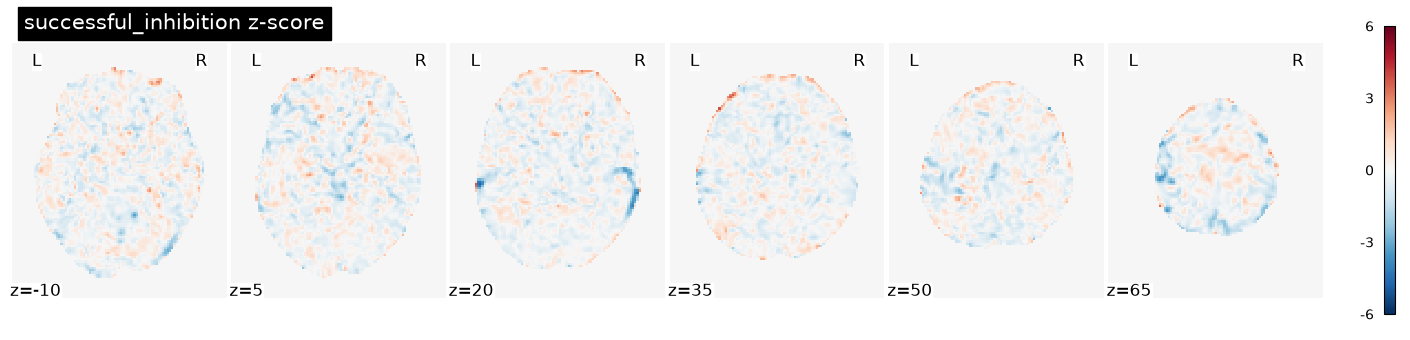

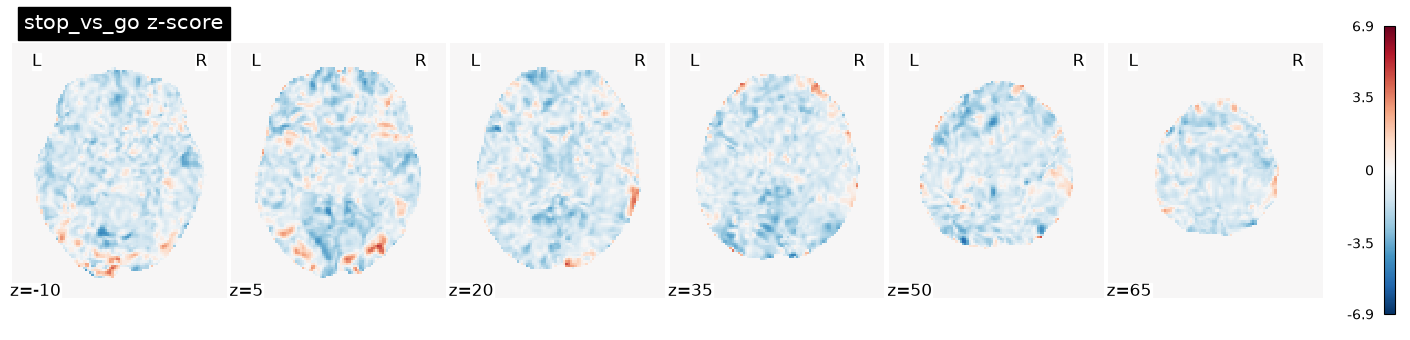

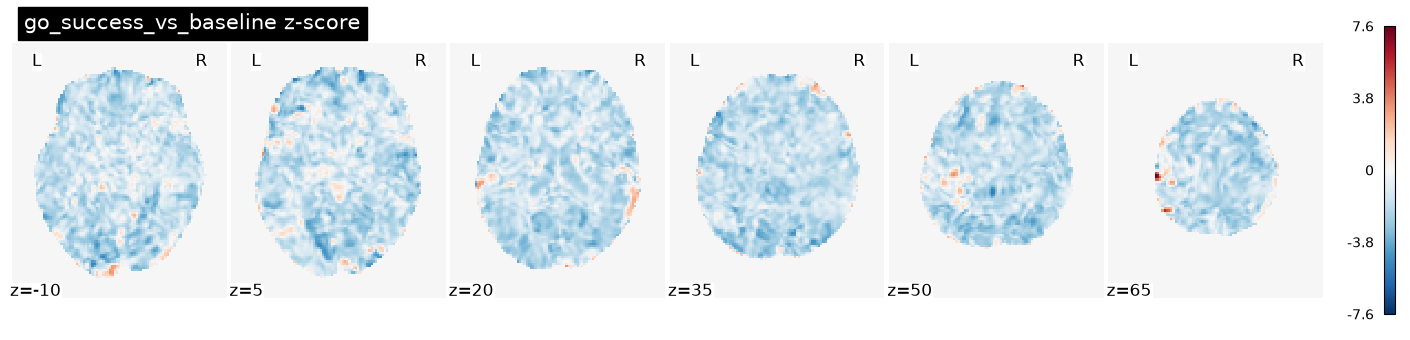

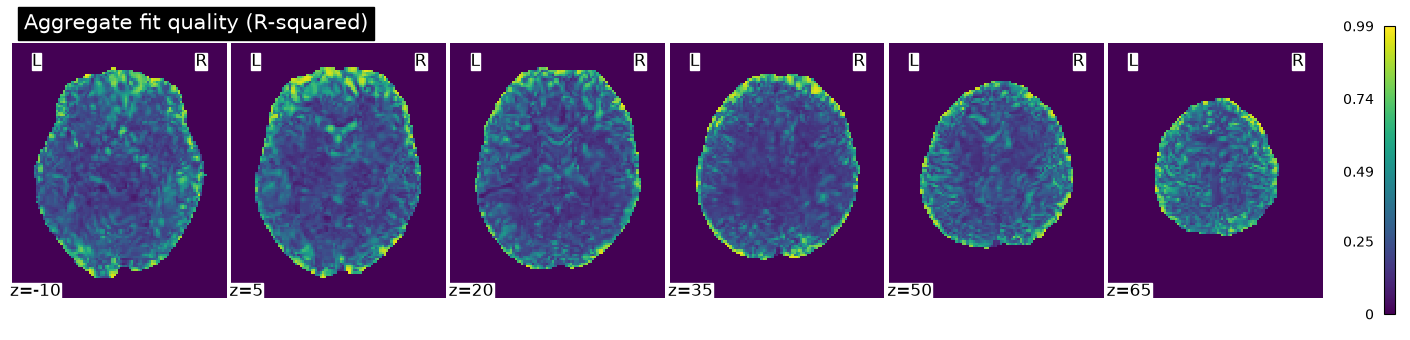

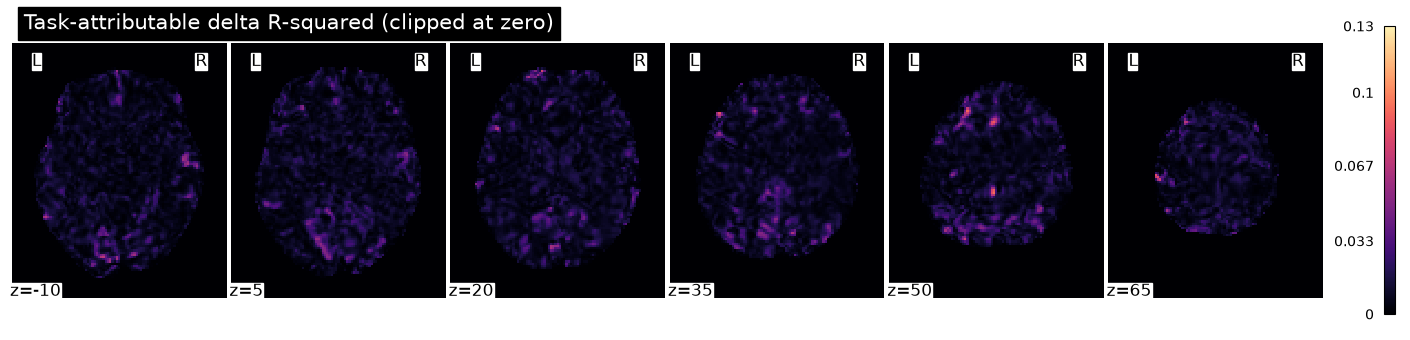

'Delta R-squared is descriptive variance accounting, not inferential evidence; negative raw differences are clipped at zero.'

'Maps are descriptive, unthresholded, and do not imply multiple-comparison-corrected inference.'

In [10]:
DISPLAY_MODE = "z"
CUT_COORDS = np.arange(-10, 70, 15)
contrast_rows = []
for contrast_name in result.contrast_names:
    contrast_rows.append(
        {
            "contrast": contrast_name,
            "mean_effect": float(np.mean(result.effect(contrast_name))),
            "mean_variance": float(np.mean(result.variance(contrast_name))),
            "mean_stat": float(np.mean(result.stat(contrast_name))),
            "mean_z_score": float(np.mean(result.z_score(contrast_name))),
            "min_one_sided_p_value": float(
                np.min(result.one_sided_p_value(contrast_name))
            ),
        }
    )
display(tuple(result.contrast_names))
display(pd.DataFrame(contrast_rows))
display(
    pd.DataFrame(
        [
            {"scope": session, "mean_r2": float(np.mean(values))}
            for session, values in zip(SESSIONS, result.run_r2, strict=True)
        ]
        + [{"scope": "aggregate", "mean_r2": float(np.mean(result.r2))}]
    )
)
display(pd.DataFrame(result.design_provenance, index=SESSIONS))
display({"warnings": [dict(item) for item in result.provenance.warnings]})
display(
    {
        "execution_id": result.provenance.execution_id,
        "analysis_fingerprint": result.provenance.analysis_fingerprint,
    }
)
for contrast_name in result.contrast_names:
    plotting.plot_stat_map(
        whole_brain_image(result.z_score(contrast_name), masker),
        display_mode=DISPLAY_MODE,
        cut_coords=CUT_COORDS,
        threshold=None,
        colorbar=True,
        title=f"{contrast_name} z-score",
    )
    plt.show()
plotting.plot_stat_map(
    whole_brain_image(result.r2, masker),
    display_mode=DISPLAY_MODE,
    cut_coords=CUT_COORDS,
    threshold=None,
    colorbar=True,
    cmap="viridis",
    symmetric_cbar=False,
    title="Aggregate fit quality (R-squared)",
)
plt.show()
plotting.plot_stat_map(
    whole_brain_image(task_delta.delta_r2, masker),
    display_mode=DISPLAY_MODE,
    cut_coords=CUT_COORDS,
    threshold=None,
    vmin=0,
    colorbar=True,
    cmap="magma",
    symmetric_cbar=False,
    title="Task-attributable delta R-squared (clipped at zero)",
)
plt.show()
display(
    "Delta R-squared is descriptive variance accounting, not inferential "
    "evidence; negative raw differences are clipped at zero."
)
display(
    "Maps are descriptive, unthresholded, and do not imply "
    "multiple-comparison-corrected inference."
)

## Structured logging and provenance

The bounded provenance history mirrors selected structured lifecycle fields rather than raw data or the full provenance record. A fresh execution ID correlates events from this fit attempt; the analysis fingerprint identifies the reproducible combination of complete source metadata and model specification.

In [7]:
event_fields = (
    "sequence",
    "stage",
    "event",
    "level",
    "execution_id",
    "analysis_id",
)
selected_events = pd.DataFrame(
    [
        {field: event.get(field) for field in event_fields}
        for event in result.provenance.events
    ]
)
display(selected_events)

,sequence,stage,event,level,execution_id,analysis_id
0,1,data,normalization_started,INFO,5de2f82b-0f38-48b1-9b02-50f06fd813eb,NaN
1,2,data,normalization_completed,INFO,5de2f82b-0f38-48b1-9b02-50f06fd813eb,NaN
2,3,fit,fit_started,INFO,89413397-6ca1-49fa-b264-400dd3f91a63,23ee8d142a0510571423092b75e43fe9c6a4f06b09463d...
3,4,fit,fit_completed,INFO,89413397-6ca1-49fa-b264-400dd3f91a63,23ee8d142a0510571423092b75e43fe9c6a4f06b09463d...


## BIDS provenance projection

The canonical record is projected in memory to stable BIDS derivative metadata plus Boldtailor's pinned BEP028 draft subset. Only derivative-relative paths and payload byte sizes are shown.

In [8]:
projected = bids_provenance.project_bids_provenance(
    task_delta.provenance,
    dataset_name="Boldtailor stop-signal example derivatives",
    label="boldtailor",
)
display(
    pd.DataFrame(
        [
            {"relative_path": path, "byte_size": len(payload)}
            for path, payload in projected.items()
        ]
    )
)

,relative_path,byte_size
0,dataset_description.json,206
1,logs/boldtailor_events.jsonl,1711
2,logs/boldtailor_provenance.json,7588
3,prov/prov-boldtailor_act.json,7304
4,prov/prov-boldtailor_ent.json,2138
5,prov/prov-boldtailor_env.json,161
6,prov/prov-boldtailor_soft.json,160
7,provenance.json,659
8,provenance.tsv,136


## Transactional publication

Projection bytes, whole-brain images, their deterministic manifest, and compact reports form one artifact set that is validated, staged, synced, and published transactionally. The safe default creates a temporary `boldtailor-*` directory. Setting `PERSIST_DERIVATIVES=True` writes only to `<dataset>/derivatives/boldtailor`; overwrite remains an explicit, separate choice.

In [9]:
artifacts = tuple(
    publication.Artifact(path, payload) for path, payload in projected.items()
)
artifacts += result_artifacts(
    result,
    masker,
    common_mask,
    subject=SUBJECT,
    task=TASK,
    sessions=SESSIONS,
    space=SPACE,
    resolution=RESOLUTION,
    configuration=shareable_configuration,
    task_delta=task_delta,
)
destination = publication_destination(
    BIDS_ROOT,
    persistent=PERSIST_DERIVATIVES,
    temporary_parent=TEMPORARY_PARENT,
)
published = publication.publish_artifact_set(
    destination,
    artifacts,
    source_paths=protected_source_paths(inputs),
    overwrite=OVERWRITE_EXISTING,
)
display(
    {
        "destination_basename": destination.name,
        "artifact_count": len(artifacts),
        "published_count": len(published),
    }
)
display(
    pd.DataFrame(
        {
            "artifact_relative_path": [
                path.relative_to(destination).as_posix() for path in published
            ]
        }
    )
)

{'destination_basename': 'boldtailor-n5lcw66n',
 'artifact_count': 25,
 'published_count': 25}

,artifact_relative_path
0,dataset_description.json
1,logs/boldtailor_events.jsonl
2,logs/boldtailor_provenance.json
3,prov/prov-boldtailor_act.json
4,prov/prov-boldtailor_ent.json
5,prov/prov-boldtailor_env.json
6,prov/prov-boldtailor_soft.json
7,provenance.json
8,provenance.tsv
9,reports/sub-s4_ses-06_task-stopSignal_desc-des...
